(class2_exercise3)=
# Exercise 3. Classification on Text Metrics
An alternative way to represent text for classification could be via metrics like [POS tag](23-parts-of-speech-analysis=) proportions, sentence length or *readability*. 

In [65]:
## CODE CHUNK REMOVED FOR USERS - HERE TO RELOAD DATA ##
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

## LOAD DATA ## 
# path of notebook
path = Path.cwd()

data_path = path.parents[1] / "resources" / "data" / "raid" / "train_none.csv"

raw_df = pd.read_csv(data_path)

## SUBSET DATA ##
df = raw_df[raw_df["model"].isin(["human", "cohere"])]

df["is_human"] = df["model"].apply(lambda x: 1 if x == "human" else 0)

## SPLIT DATA ##
train_df, val_df= train_test_split(
                                                    df,
                                                    test_size=0.20,
                                                    random_state=42,
                                                    stratify=df["is_human"]
                                                    )

/var/folders/gg/gk923hkx2w3bw72pk2shplydry9j0b/T/ipykernel_3212/1245980808.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["is_human"] = df["model"].apply(lambda x: 1 if x == "human" else 0)


In [66]:
# THIS CHUNK IS HIDDEN FROM USERS - FUNCTIONS TO FIT AND EVALUATE CLASSIFIER FROM LAST NOTEBOOK ##
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def clf_fit(X_train, y_train, random_state=42):
    """
    Fit a classifier on X and Y

    Could for example be X_train = X_train_bow and y_train = train_df['is_human']
    """
    clf = LogisticRegression(
    random_state=random_state,
    solver="liblinear",   # better for small/medium sparse datasets
    max_iter=1000,        # allow more iterations
    C=1.0,                # adjust if needed (smaller values = stronger regularization)
    )

    clf.fit(X_train, y_train)

    return clf

def clf_evaluate(clf_fitted, X_val, y_val):
    """
    Evaluate fitted classifier, extracting y_pred from X_val, and creating a classification report
    """
    y_pred = clf_fitted.predict(X_val)

    report = classification_report(y_val, y_pred)

    return report, y_pred 

## 3.1 Installing TextDescriptives
For this, we'll install the TextDescriptives package. This was actually developed by former cogsci legends {cite:t}`hansen_textdescriptives_2023`!!

In [67]:
%pip install textdescriptives==2.8.4


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


We also need to install *spacy* again!

In [68]:
%pip install spacy==3.8.7
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.8 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 3.2 Extract Metrics

Import `textdescriptives` and `spacy`:

In [69]:
import textdescriptives as td
import spacy

Load our model:

In [70]:
nlp = spacy.load("en_core_web_sm")

We then add "text_descriptives" to our nlp pipeline (*remember the components in {numref}`pos-tag-figure` with "ner" and "tagger" - this is the same idea!)

In [71]:
nlp.add_pipe("textdescriptives/all")

Add our texts as `docs` (note: this is my train_df with `cohere` as defined in exercise 1):

In [103]:
train_docs = nlp.pipe(train_df["generation"], batch_size=16, n_process=-1) # use -1 to use all available cores. this way, if you have a larger machine, it will actually be more efficient.
val_docs = nlp.pipe(val_df["generation"], batch_size=16, n_process=-1)

### Your turn: Find Metrics to Extract
:::{admonition} HANDS-ON
:class: red
You can extract metrics as such: 
```python
train_metrics_df = td.extract_df(
                                    train_docs, 
                                    include_text=True, 
                                    metrics=["..", ".."] # this is pseudocode - check task!
                                    )
```
The additional `metrics` is not defined correctly in the snippet above. This is because I want you to choose which kinds of metrics you want (can be passed as a list).

**YOUR TASK**

1. Check the [docs](https://hlasse.github.io/TextDescriptives/extractors.html#textdescriptives.extractors.extract_df) and decide on which kinds of metrics you want to extract!
2. Extract the metrics for both `train_df` and `val_df`
3. Print one of the `metrics_df` to see how it looks!
:::

Solution:

In [104]:
train_metrics_df = td.extract_df(
                                    train_docs, 
                                    include_text=True, 
                                    metrics=["readability", "descriptive_stats"] # you can add more metrics here if you want!
                                    )

val_metrics_df = td.extract_df(
                                    val_docs, 
                                    include_text=True, 
                                    metrics=["readability", "descriptive_stats"] # you can add more metrics here if you want!
)

# might give a coherence warning, but I'm not extracting coherence here, so we'll ignore it!

/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/textdescriptives/components/coherence.py:44: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Span.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  similarities.append(sent.similarity(sents[i + order]))
/Users/au675000/Desktop/teaching/book.nosync/nlp-at-cogsci/.venv/lib/python3.12/site-packages/textdescriptives/components/coherence.py:44: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Span.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgemen

You should have something like this (with your chosen metrics):

In [106]:
print(train_metrics_df.columns.tolist())

['text', 'flesch_reading_ease', 'flesch_kincaid_grade', 'smog', 'gunning_fog', 'automated_readability_index', 'coleman_liau_index', 'lix', 'rix', 'token_length_mean', 'token_length_median', 'token_length_std', 'sentence_length_mean', 'sentence_length_median', 'sentence_length_std', 'syllables_per_token_mean', 'syllables_per_token_median', 'syllables_per_token_std', 'n_tokens', 'n_unique_tokens', 'proportion_unique_tokens', 'n_characters', 'n_sentences']


## 3.3 Combine with Train and Val
Let's start by renaming the `text` column from our `metrics` dfs:

In [107]:
train_metrics_df = train_metrics_df.rename(columns={"text": "generation"})
val_metrics_df = val_metrics_df.rename(columns={"text": "generation"})

Let's use the `pd.merge` to combine the two dataframes on their shared column:

In [126]:
train_df_with_metrics = pd.merge(train_df, train_metrics_df.drop_duplicates(), on="generation") # for some reason, there were duplicate rows in metrics_df, so I dropped them first
val_df_with_metrics = pd.merge(val_df, val_metrics_df.drop_duplicates(), on="generation")

Check they are same length:

In [149]:
print(len(train_df_with_metrics), len(val_df_with_metrics))
print(len(train_df), len(val_df))

32090 8023
32090 8023


## 3.4 Remove NA's
Our logistic regression doesn't do well with NA's and we have a few of them from `textdescriptives`:

In [128]:
# print where NAN
print(train_df_with_metrics.isna().sum())

id                                 0
adv_source_id                      0
source_id                          0
model                              0
decoding                       10697
repetition_penalty             10697
attack                             0
domain                             0
title                              0
prompt                         10697
generation                         0
is_human                           0
flesch_reading_ease                1
flesch_kincaid_grade               1
smog                             497
gunning_fog                        1
automated_readability_index        1
coleman_liau_index                 1
lix                                1
rix                                1
token_length_mean                  1
token_length_median                1
token_length_std                   1
sentence_length_mean               0
sentence_length_median             0
sentence_length_std                0
syllables_per_token_mean           1
s

Let's only drop NA's based on the metrics that we are interested in such as  `smog`. If we don't specify a `subset`, we will end up dropping all `human` completions (since `human` always has NA for e.g., `prompt`):

In [ ]:
# now we can drop na's!
train_metrics_filtered = train_df_with_metrics.dropna(
    subset=["smog", "flesch_reading_ease", "automated_readability_index"] # only drop rows where these cols are NA
)  

val_metrics_filtered = val_df_with_metrics.dropna(
    subset=["smog", "flesch_reading_ease", "automated_readability_index"]
)

## 3.4 Classify Metrics
You should now have a dataframes containing metrics for both `train` and `val` that are also filtered! We'll select the metrics:

In [ ]:
metrics_to_use = ["flesch_reading_ease", "sentence_length_median", "n_unique_tokens", "n_tokens", "automated_readability_index"] # you can change these to whatever you want!

# define X and y with filtered data
X_train = train_metrics_filtered[metrics_to_use]
X_val = val_metrics_filtered[metrics_to_use]

### Your Turn: Use Your Pipeline Functions !

:::{admonition} HANDS-ON
:class: red
Now you'll reap the benefits of having defined functions in exercise 2:
- Select the metrics you are interested in classifying and create `X_train` and `X_val` 
    - Remember to copy the "remove NA" part if your metrics also contain a few NA's!
- Use the functions from your pipeline that are relevant to fit and evaluate a classifier on your new *metric* features! 
- Compare the results to BOW/TF-IDF. Are they worse? Or better?
- Try to play with a few different metric combinations (does it help that there are more?)
:::

#### Solution:
My solution, you might have another!

In [199]:
clf = clf_fit(X_train, train_metrics_filtered['is_human'])
report, y_pred = clf_evaluate(clf, X_val, val_metrics_filtered['is_human'])
print(report)

# It seems much worse than our BOW/TF-IDF approaches .. 

              precision    recall  f1-score   support

           0       0.69      0.94      0.80     21007
           1       0.58      0.17      0.26     10585

    accuracy                           0.68     31592
   macro avg       0.64      0.55      0.53     31592
weighted avg       0.65      0.68      0.62     31592



## 3.5 Explainable ML with SHAP values (OPTIONAL)
This final task is optional! 
Despite how the results may or may not have turned out, it might be fun to try to look into *what* kind of features were important for our classification. We can do this by extracting SHAP values.

> Note: This only works properly if you choose metrics that don't heavily correlate. If they do so, it will be make our interpretation unstable. Perhaps choosing "n_tokens" and "n_sentences" is too risky.

Let's start by installing and importing `shap`:

In [201]:
%pip install shap
import shap


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Run SHAP

In [217]:
background = shap.sample(X_train, 100)  # randomly sample 100 rows for "background" in the KERNEL explainer, then processing entire validation
explainer = shap.KernelExplainer(clf.predict_proba, background)
shap_values = explainer(X_val) # see https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/migrating-to-new-api.html

100%|██████████| 31592/31592 [01:06<00:00, 473.40it/s]


Let's print its shape! It looks like it contains all our 31592 rows, our 5 features, and explanations for EACH of our class seperately:

In [228]:
print(shap_values.shape)

(31592, 5, 2)


### Plot SHAP

Let's plot explanations with respect to class 0 by selecting the index `0` on the last dimension (of our shape `(31592, 5, 2)`).

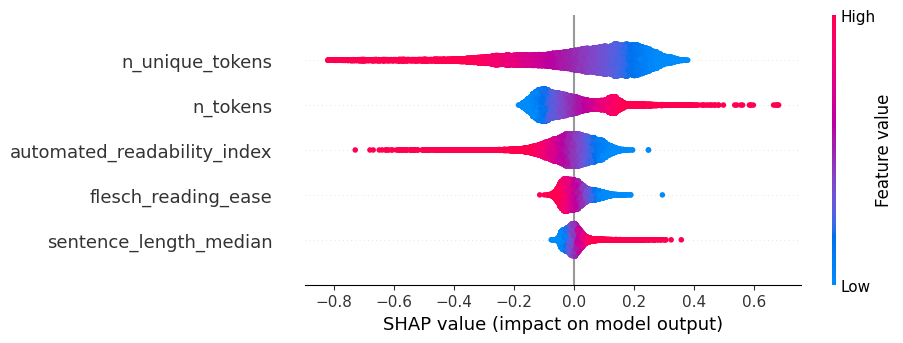

In [268]:
shap.plots.beeswarm(shap_values[:,:,0])

Let's plot explanations for class 1 (our llm class), by selecting the index `1` on the last dimension (of our shape `(31592, 5, 2)`):

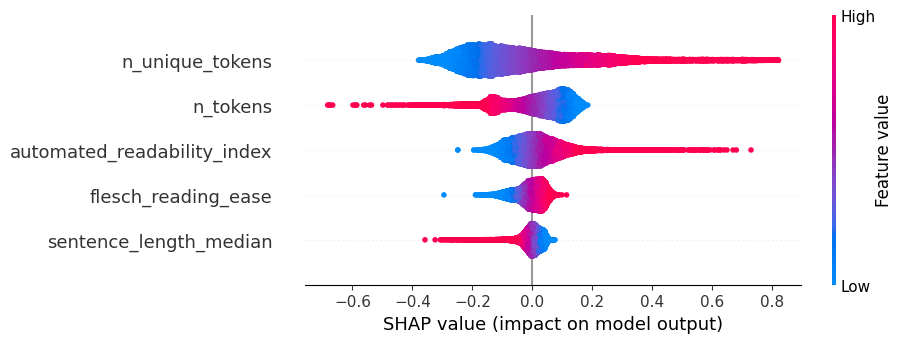

In [226]:
shap.plots.beeswarm(shap_values[:,:,1])

:::{admonition} HANDS-ON
:class: red
Whaaaaat is happening on this plot? See if you can find out how this should be interpreted!
- Try to skim through Aidan Cooper's [blog post](https://www.aidancooper.co.uk/a-non-technical-guide-to-interpreting-shap-analyses/). If that doesn't help, look at the SHAP library [docs](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html). Finally, there is also this [blogpost](https://towardsdatascience.com/explain-machine-learning-models-using-shap-library-e05a1583c34f/) from **TowardsDataScience**.

As a final task, try to run this SHAP workflow on your own chosen metrics!
:::

:::{warning} 
Note that like everything else, SHAP values can also be unreliable. Read more about their [limitations](https://christophm.github.io/interpretable-ml-book/shap.html#limitations). See also [Be careful when interpreting predictive models in search of causal insights](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/Be%20careful%20when%20interpreting%20predictive%20models%20in%20search%20of%20causal%20insights.html)
:::